# Neuro-Symbolic PPM — Sepsis_Case (T-LEAF · noise × data-scarcity)

**The question.** Following the PPM pipeline `event log → prefix log → encoding → learning → validation → runtime prediction`, does **clean symbolic temporal knowledge** keep a neural next-activity model accurate and process-conformant when its training data is both **scarce** and **noisy**?

We mine the symbolic layer — an empirical **directly-follows DFA** and **LTLf precedence** rules `a precedes b ≡ (¬b U a) ∨ G(¬b)` — **once, from the full clean training set**, and hold it fixed. Then we vary only the *neural* training data along two crossed axes:

- **data scarcity** — nested training subsets `1 ⊃ 1/2 ⊃ 1/4 ⊃ 1/8` of the cases;
- **label noise** — corrupt 0 / 10 / 25 / 40 % of the (subset's) training targets with a random DFA activity.

Validation and test stay clean and fixed, so every grid cell is comparable.

Four variants × two architectures (GRU, LSTM):
- **baseline** — cross-entropy only;
- **baseline+mask** — baseline weights, DFA-forbidden classes removed at inference (output refinement);
- **checker** — trained with the differentiable forbidden-mass logic loss (T-LEAF *checker*);
- **embedder** — trained with the T-LEAF embedding logic loss `‖q(A) − q(w_pred)‖²` (skill `TLEAF`).

> Background skills: `ppm-skills` (PPM pipeline) · `TLEAF` (LTLf, DFA embedding, logic loss) · `dtl-temp-logic-skill` (differentiable temporal logic).
>
> **Design note.** The symbolic layer (vocabulary, DFA, constraints, embedder) is built from the *full clean* training set and reused across the whole grid — this is the "clean knowledge vs dirty/scarce data" hypothesis, and keeps the test set and output space fixed for comparability.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import pandas as pd
import torch
from IPython.display import Image, display

# Make `src.nspm` importable from anywhere under the repository.
ROOT = Path.cwd()
while not (ROOT / "src" / "nspm").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nspm.config import ExperimentConfig, ProjectPaths
from src.nspm.data.loader import read_xes
from src.nspm.data.preparation import ActivityVocabulary, TraceSplits, TraceUtils
from src.nspm.pipeline.analysis import build_analysis_tables, summarise, SEPSIS_OUTCOME_MARKERS
from src.nspm.process.automaton import ProcessDFA
from src.nspm.process.graph_encoding import FeatureSpace
from src.nspm.process.ltl_constraints import mine_precedence_constraints
from src.nspm.learning.logic import EmbeddingLogicLoss, build_allowed_mask
from src.nspm.learning.embedder import HierarchicalEmbedder
from src.nspm.learning.embedder_training import EmbedderConfig, train_embedder
from src.nspm.learning.training import resolve_device
from src.nspm.pipeline.benchmark import run_corruption_grid
from src.nspm.visualization import plots

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
device = resolve_device("auto")
print("device:", device)

device: cuda


## 1. Configuration

The **only** difference between the three dataset notebooks is `DATASET_NAME`.
`FORCE_RERUN=False` reuses the cached grid in `runs/benchmark_corruption.csv`, so
re-opening the notebook is cheap; set it to `True` to recompute from scratch.

In [2]:
# --- experiment parameters (only DATASET_NAME differs across the three notebooks) ---
DATASET_NAME    = "Sepsis_Case"

MODELS          = ["gru", "lstm"]                 # transformer wired but off for now
VARIANTS        = ["baseline", "baseline_mask", "checker", "embedder"]
NOISE_LEVELS    = [0.0, 0.1, 0.25, 0.4]           # fraction of training targets corrupted
TRAIN_FRACTIONS = [1.0, 0.5, 0.25, 0.125]         # nested subsets of training cases
EPOCHS          = 30                              # long runs; early stopping cuts most short
EMBEDDER_EPOCHS = 5
LOGIC_WEIGHT    = 0.5
SEED            = 42
DROP_UNSEEN     = True                            # drop held-out cases with unseen activities
MAX_CASES       = None                            # cap cases for a quick smoke run
FORCE_RERUN     = False                           # recompute even if cached results exist

In [3]:
config = ExperimentConfig(seed=SEED)
paths = ProjectPaths.from_root(ROOT, DATASET_NAME)
DATA_PATH = paths.dataset
OUTPUT_DIR = ROOT / "runs" / DATASET_NAME / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = ROOT / "runs" / "benchmark_corruption.csv"
print("dataset :", DATASET_NAME)
print("log file:", DATA_PATH.name)

dataset : Sepsis_Case
log file: Sepsis_Cases_Event_Log.xes


## 2. The event log — exploration

Load the XES log once and explore it: a compact summary, the activity frequency,
case-duration distribution and the most common variants. (We pass
`outcome_markers={}` so the case table carries no dataset-specific outcome flags
— those are a Sepsis-only preset.)

In [4]:
events = read_xes(DATA_PATH, max_cases=MAX_CASES)
tables = build_analysis_tables(events, outcome_markers=SEPSIS_OUTCOME_MARKERS)
summary = summarise(tables, DATA_PATH)
print(json.dumps({k: summary[k] for k in ["cases", "events", "activities", "variants"]}, indent=2))
display(tables.activities.head(10))

{
  "cases": 1050,
  "events": 15214,
  "activities": 16,
  "variants": 846
}


C:\Users\Matteo\miniconda3\envs\tleaf\lib\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


,concept:name,count
0,Leucocytes,3383
1,CRP,3262
2,LacticAcid,1466
3,Admission NC,1182
4,ER Triage,1053
5,ER Registration,1050
6,ER Sepsis Triage,1049
7,IV Antibiotics,823
8,IV Liquid,753
9,Release A,671


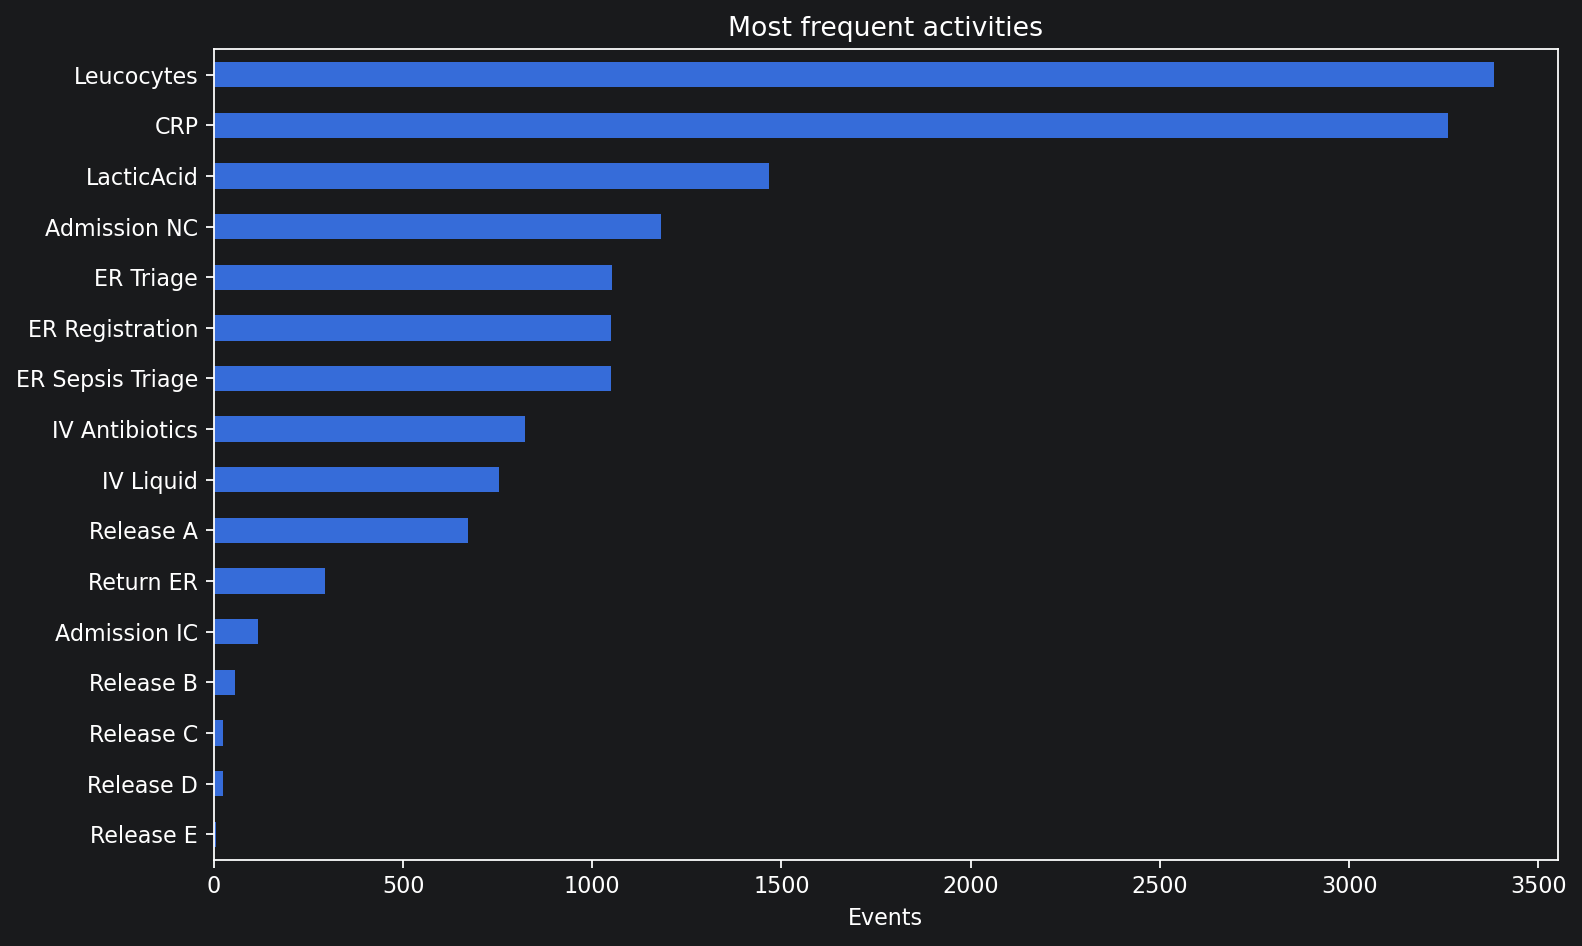

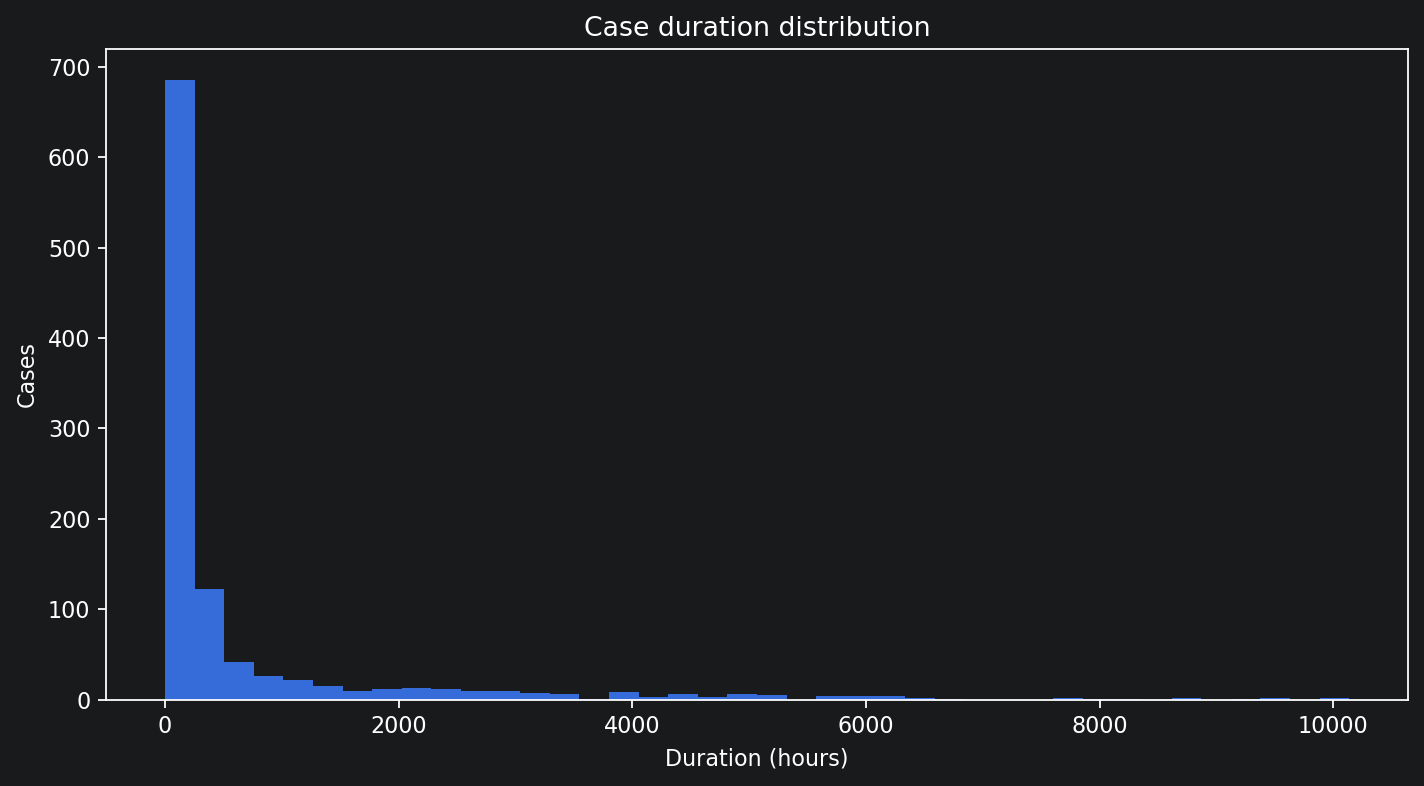

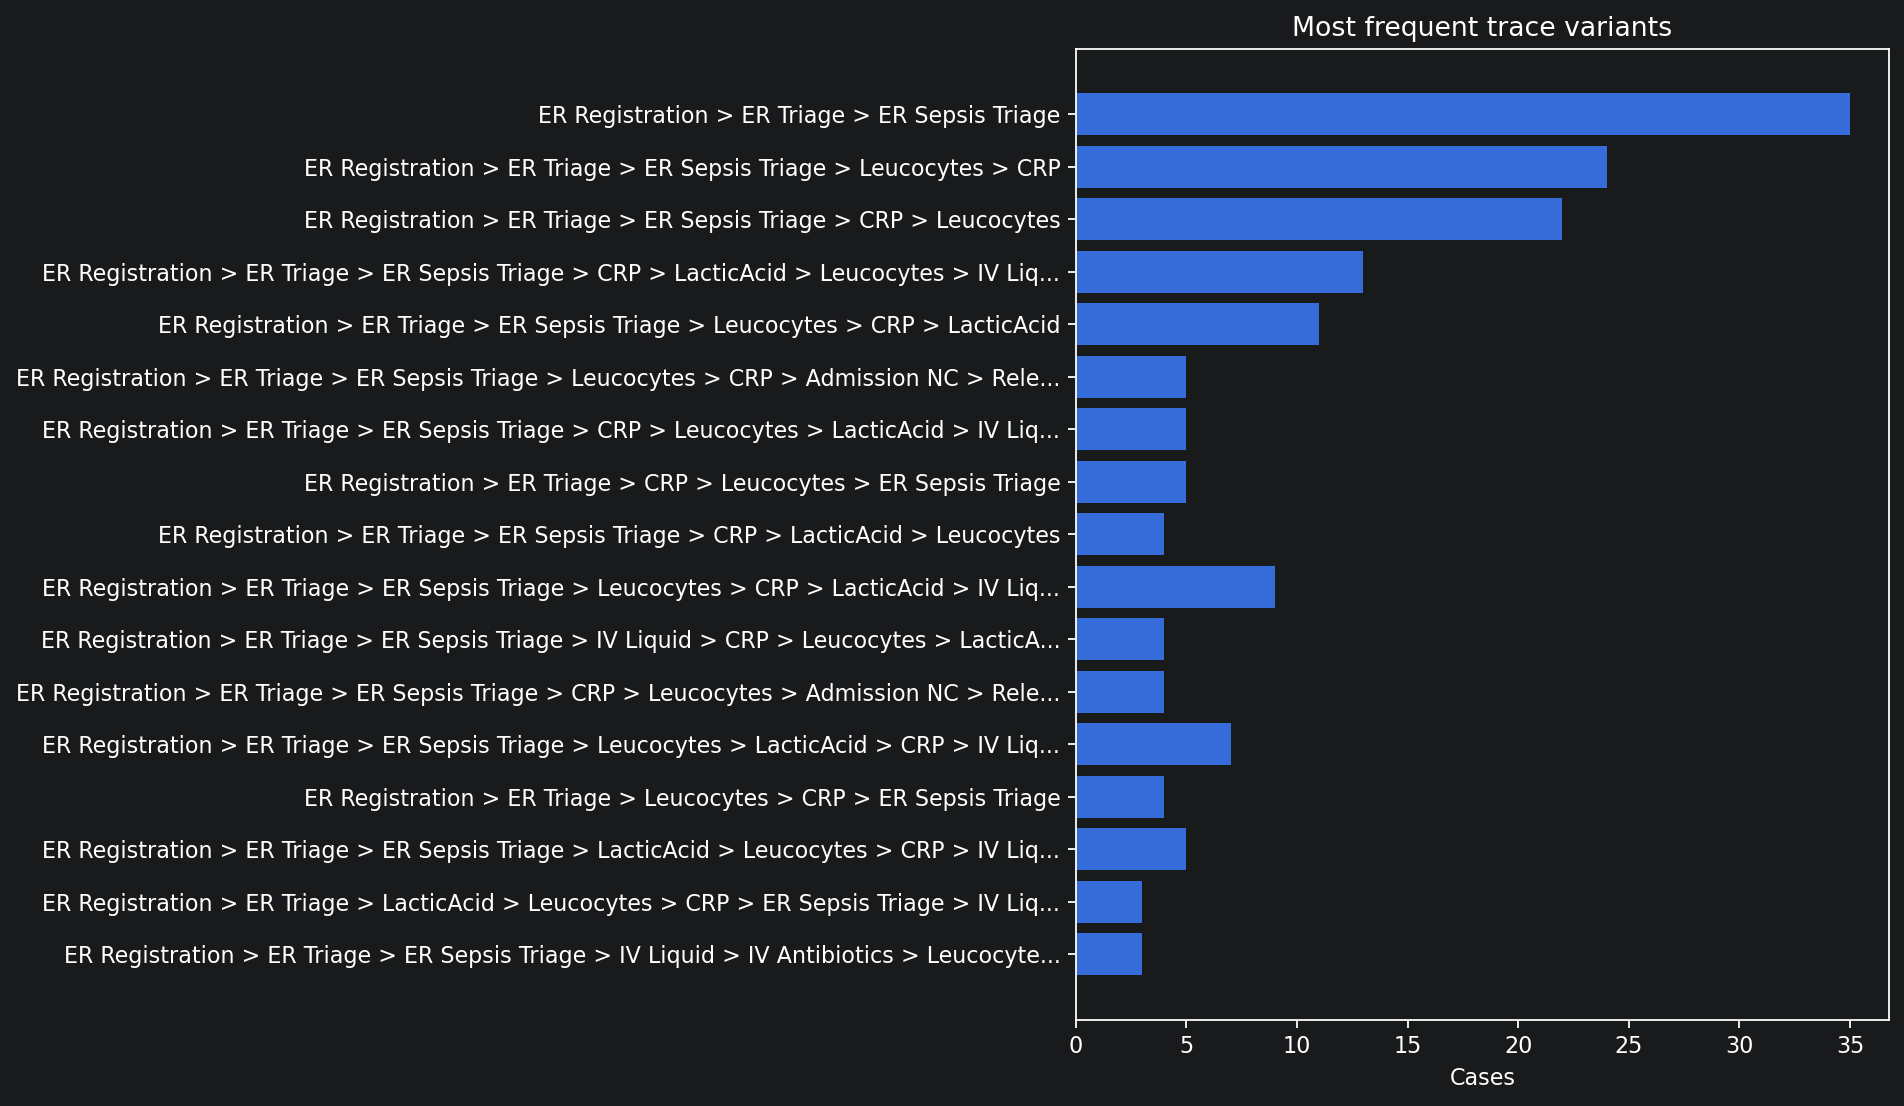

In [5]:
plots.plot_activity_frequency(events, OUTPUT_DIR / "activity_frequency.png")
plots.plot_case_durations(tables.cases, OUTPUT_DIR / "case_durations.png")
plots.plot_variants(tables.variants, OUTPUT_DIR / "top_variants.png")
for name in ["activity_frequency", "case_durations", "top_variants"]:
    display(Image(filename=str(OUTPUT_DIR / f"{name}.png")))

## 3. From log to a supervised learning problem

We **split by case id** (no case's prefixes leak across train/val/test), build the
**activity vocabulary**, and generate one prefix → next-activity example per
event.

In [6]:
traces = TraceUtils.extract_traces(events)
splits = TraceSplits.from_traces(
    traces,
    validation_fraction=config.data.validation_fraction,
    test_fraction=config.data.test_fraction,
    seed=config.seed,
)
vocab = ActivityVocabulary.from_traces(splits.train.values())
n_prefix = sum(len(t) for t in splits.train.values())
print(f"cases  train / val / test : {len(splits.train)} / {len(splits.validation)} / {len(splits.test)}")
print(f"activities (vocabulary)   : {len(vocab.activities)}")
print(f"training prefix examples  : {n_prefix}")

cases  train / val / test : 735 / 157 / 158
activities (vocabulary)   : 16
training prefix examples  : 10740


## 4. The symbolic knowledge: a DFA and LTLf precedence rules — from the **clean** full training set

Two symbolic objects, mined from clean training traces only and held fixed:

- the empirical **directly-follows DFA** — it powers the **checker** loss and the
  inference-time decoding mask;
- mined **LTLf precedence** rules `a precedes b ≡ (¬b U a) ∨ G(¬b)`, each a tiny
  3-state DFA — the knowledge the **embedder** learns.

In [7]:
automaton = ProcessDFA.from_traces(splits.train.values())
mask = build_allowed_mask(automaton, vocab)
constraints = mine_precedence_constraints(
    splits.train.values(),
    min_support=max(3, len(splits.train) // 10),
    min_confidence=0.95,
    max_constraints=15,
)
print(f"DFA: {len(automaton.states)} states, {automaton.transition_count} transitions")
print(f"test transition coverage: {automaton.transition_coverage(splits.test.values()):.3f}")
print(f"mined LTLf precedence constraints: {len(constraints)}")
display(pd.DataFrame(
    [{"earlier": c.earlier, "later": c.later, "support": c.support,
      "confidence": round(c.confidence, 3), "LTLf": c.to_ltlf()} for c in constraints]
))

DFA: 18 states, 128 transitions
test transition coverage: 0.999
mined LTLf precedence constraints: 15


,earlier,later,support,confidence,LTLf
0,ER Sepsis Triage,IV Antibiotics,563,1.000,(!'IV Antibiotics' U 'ER Sepsis Triage') | G(!...
1,ER Registration,Admission NC,551,1.000,(!'Admission NC' U 'ER Registration') | G(!'Ad...
2,ER Triage,Admission NC,551,1.000,(!'Admission NC' U 'ER Triage') | G(!'Admissio...
3,ER Registration,Release A,465,1.000,(!'Release A' U 'ER Registration') | G(!'Relea...
4,ER Triage,Release A,465,1.000,(!'Release A' U 'ER Triage') | G(!'Release A')
5,Admission NC,Return ER,205,1.000,(!'Return ER' U 'Admission NC') | G(!'Return ER')
6,ER Registration,Return ER,205,1.000,(!'Return ER' U 'ER Registration') | G(!'Retur...
7,ER Triage,Return ER,205,1.000,(!'Return ER' U 'ER Triage') | G(!'Return ER')
8,CRP,Return ER,205,1.000,(!'Return ER' U 'CRP') | G(!'Return ER')
9,ER Registration,Admission IC,81,1.000,(!'Admission IC' U 'ER Registration') | G(!'Ad...


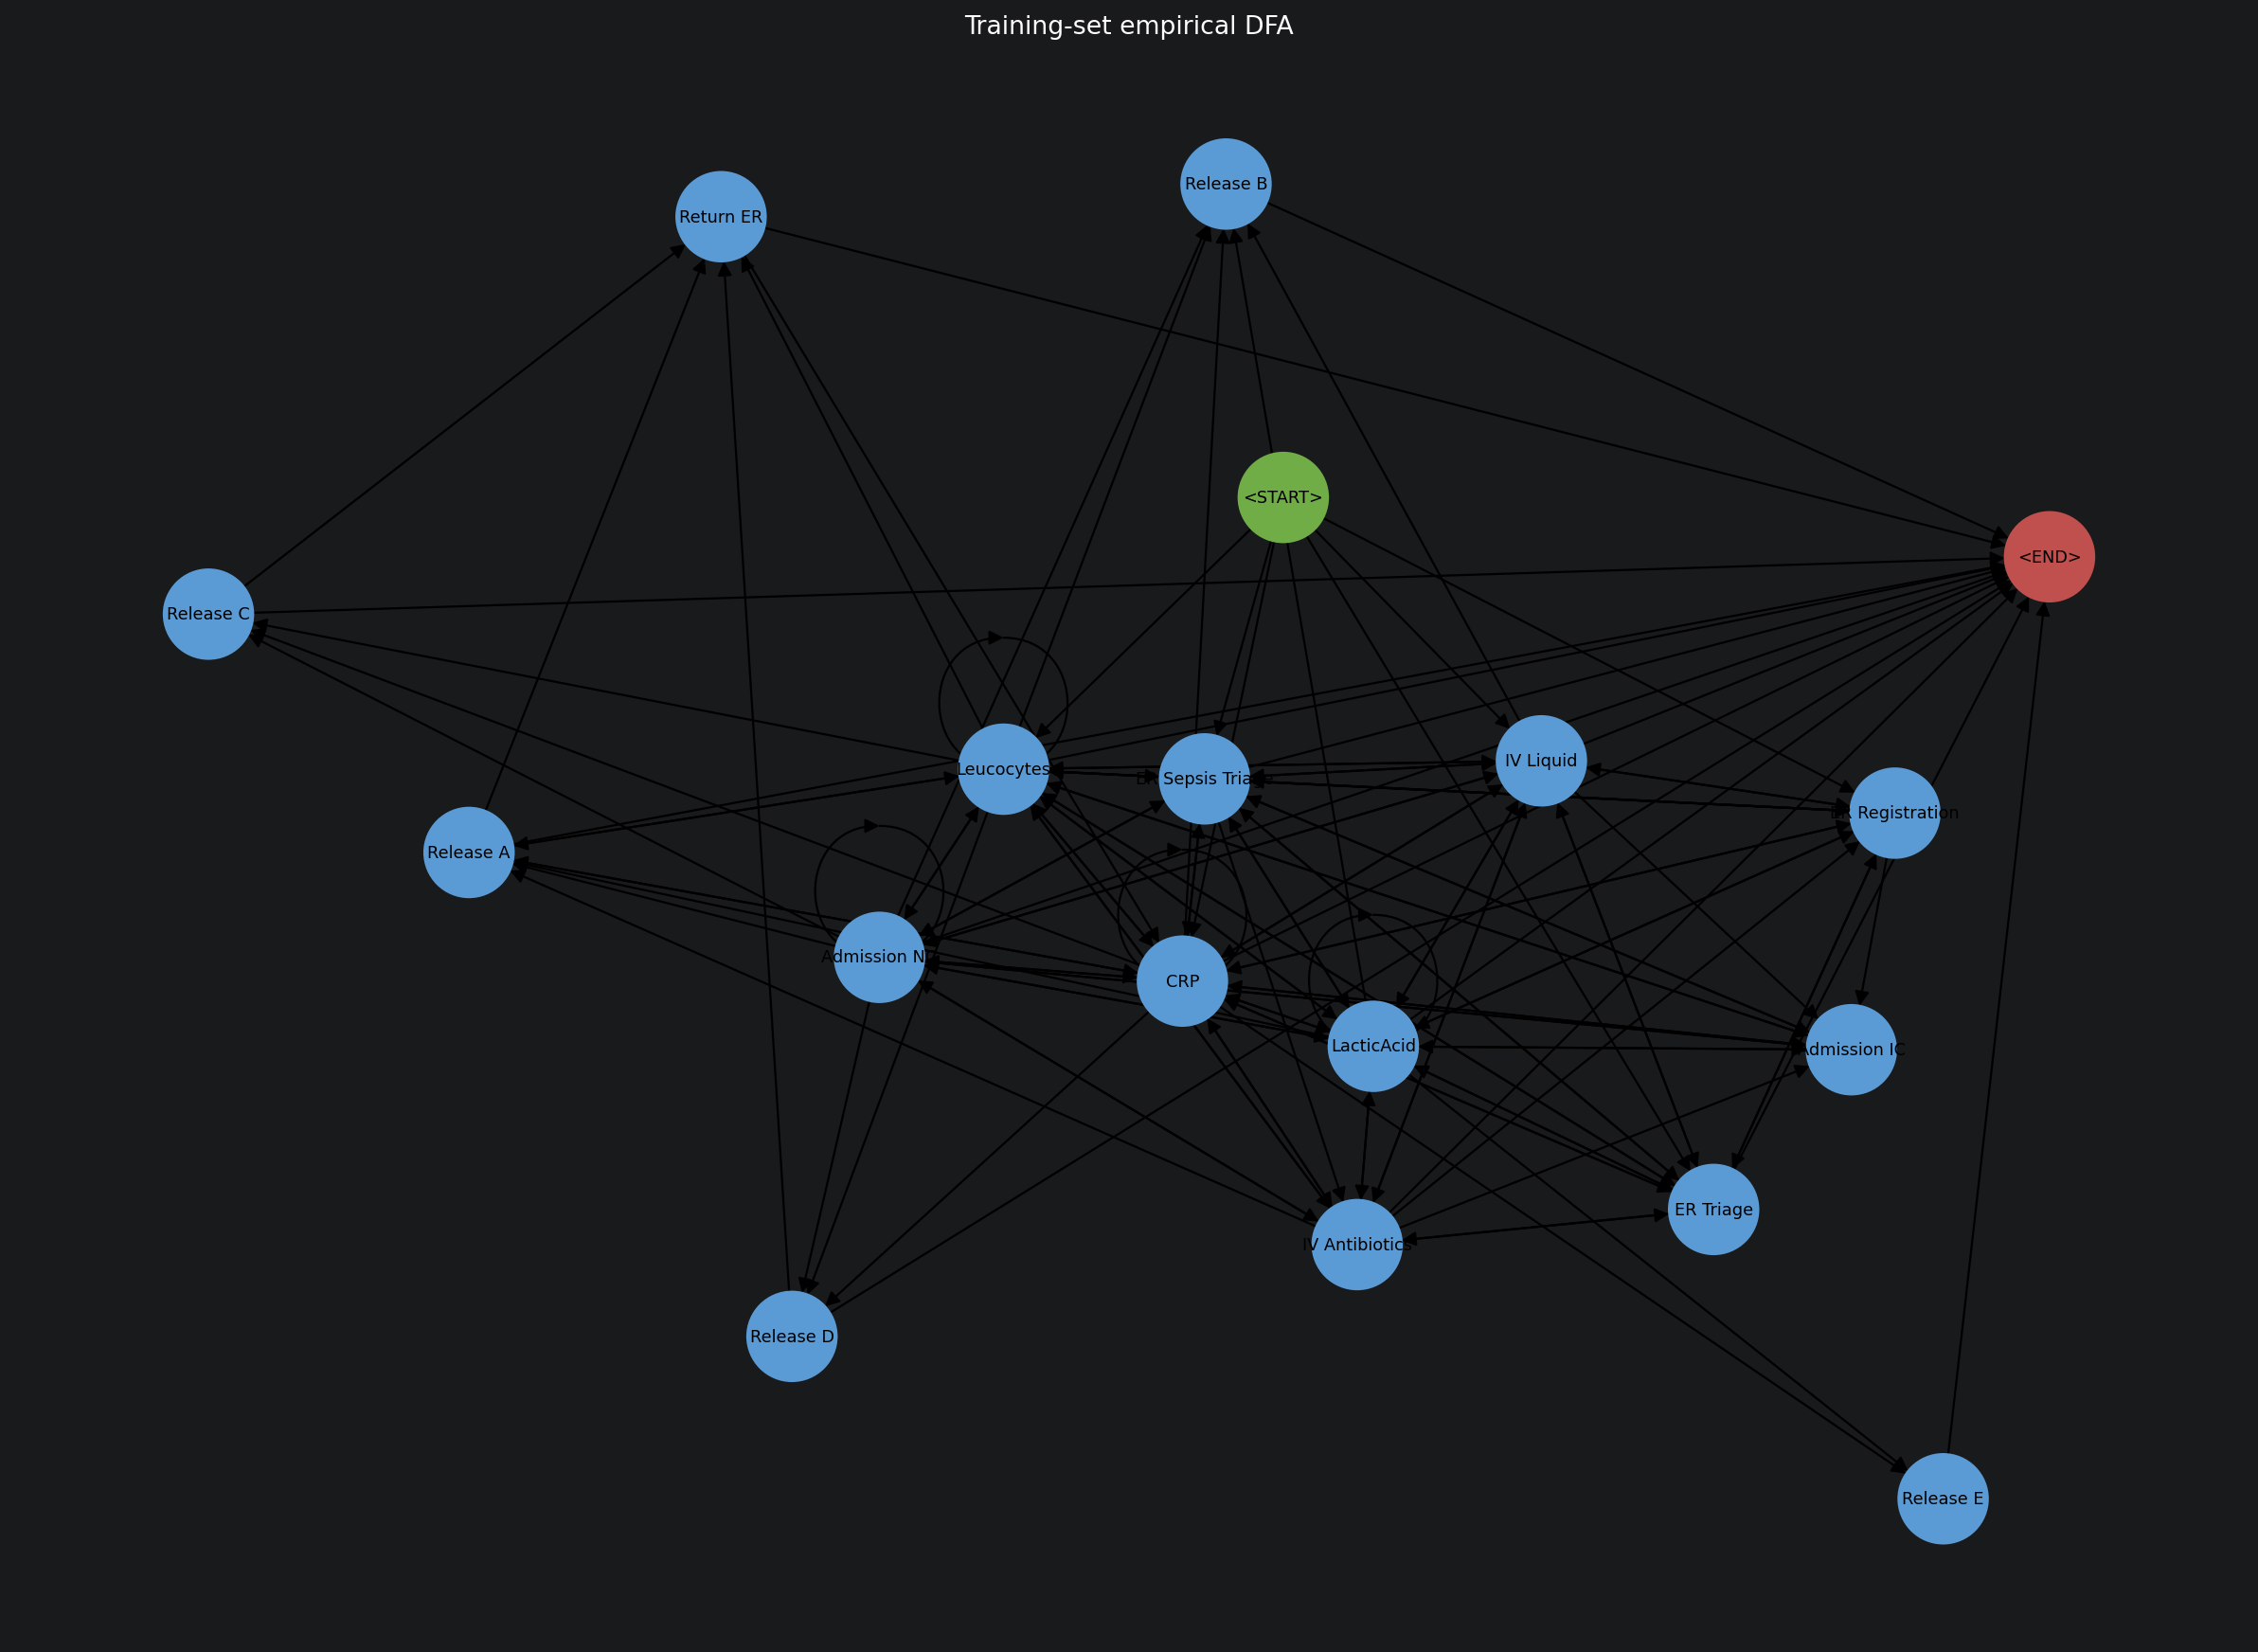

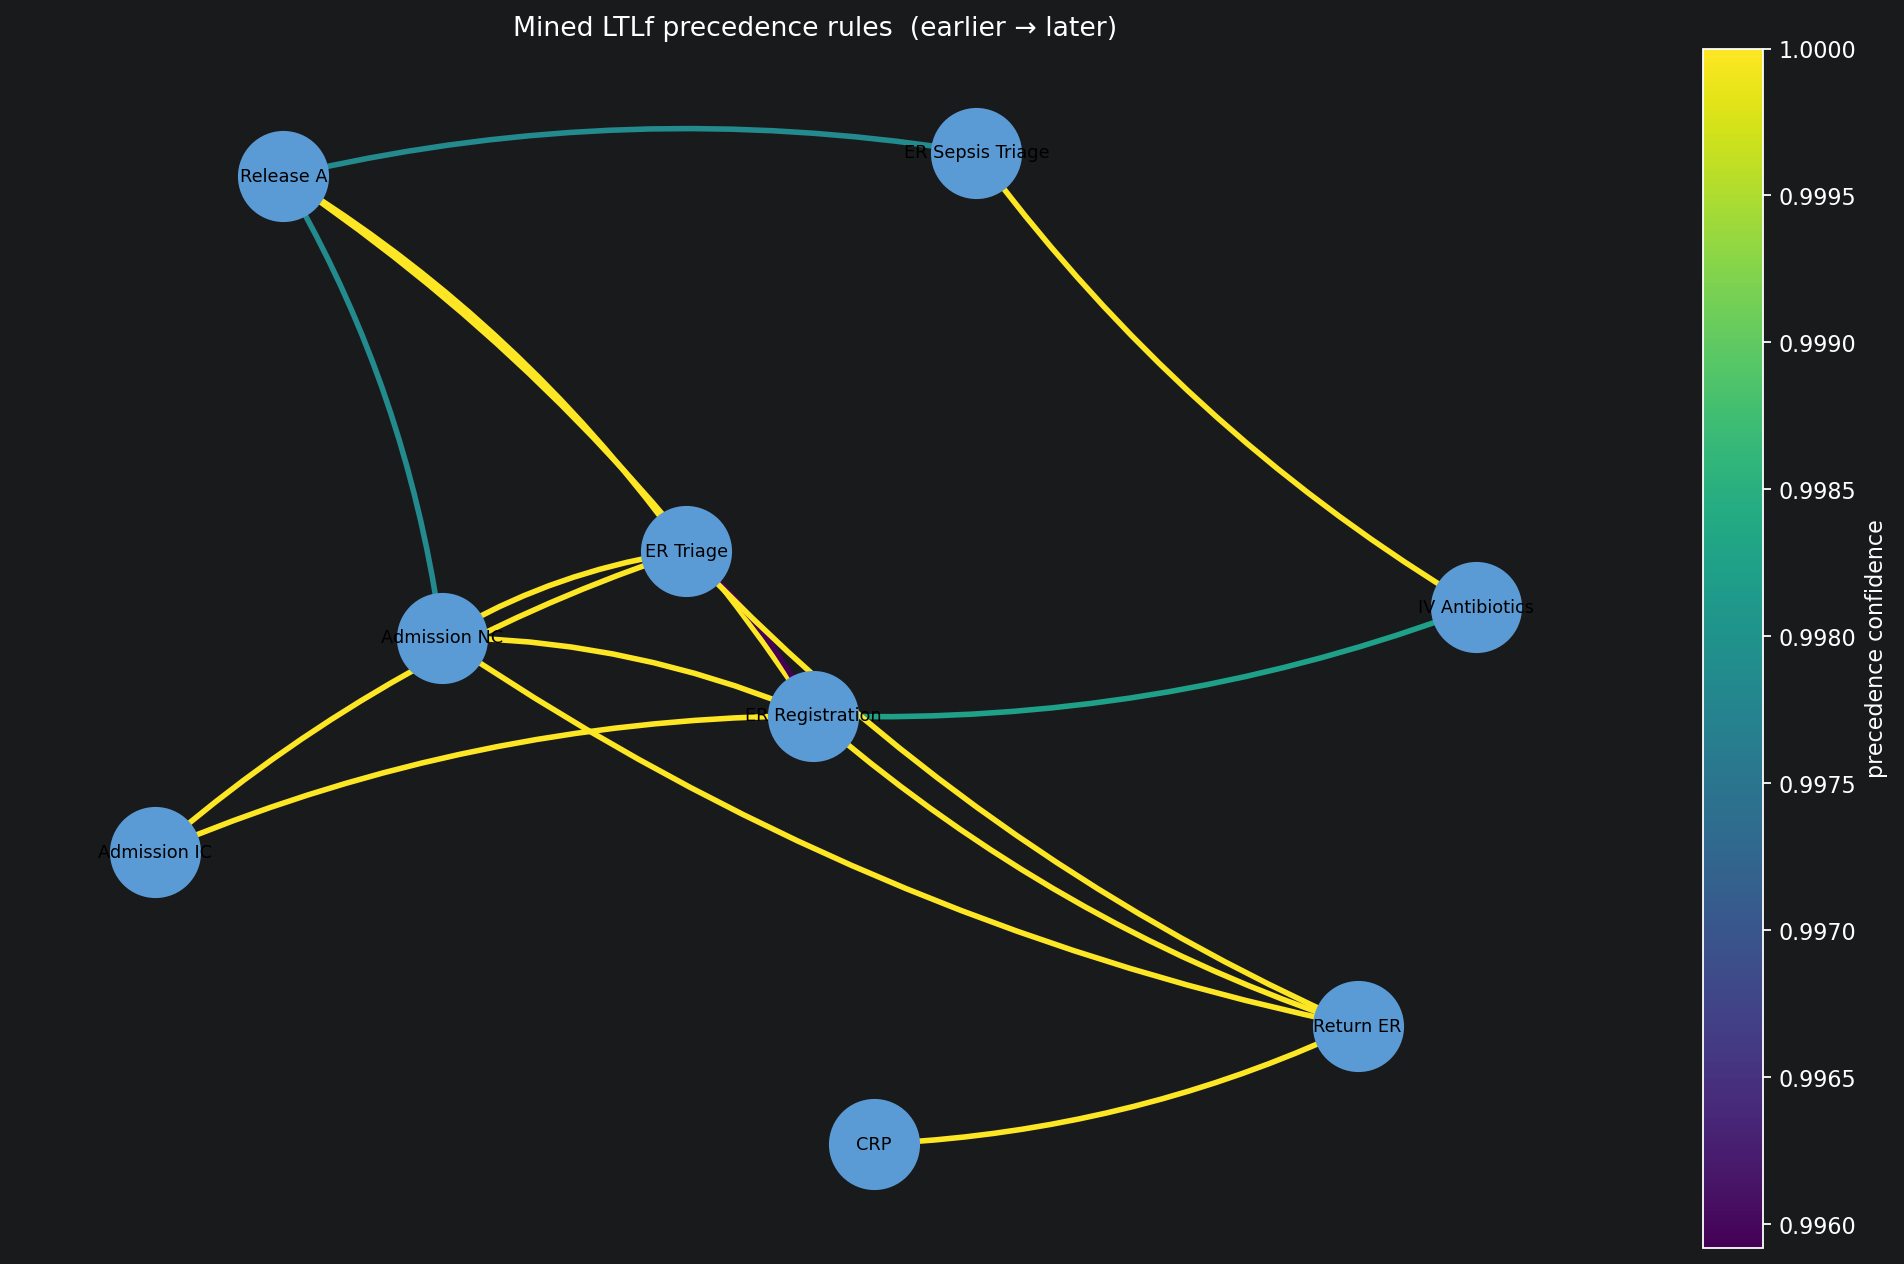

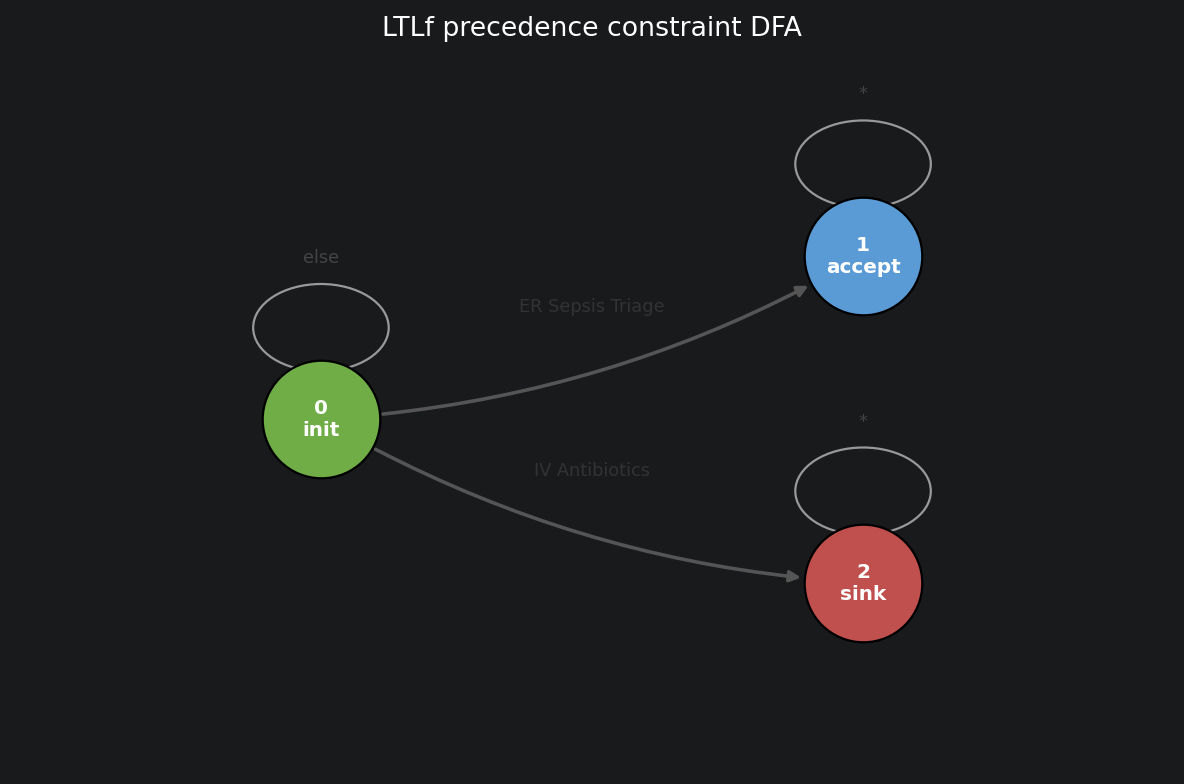

In [8]:
plots.plot_automaton(automaton, OUTPUT_DIR / "dfa.png")
display(Image(filename=str(OUTPUT_DIR / "dfa.png")))
if constraints:
    plots.plot_precedence_constraints(constraints, OUTPUT_DIR / "constraints.png")
    plots.plot_constraint_dfa(constraints[0].to_dfa(), OUTPUT_DIR / "constraint_dfa.png")
    display(Image(filename=str(OUTPUT_DIR / "constraints.png")))
    display(Image(filename=str(OUTPUT_DIR / "constraint_dfa.png")))

## 5. Embedding the knowledge (the T-LEAF embedder)

T-LEAF embeds each constraint DFA and each predicted trace into a shared vector
space with a hierarchical GNN `q = (qe, qm)`, trained by a **triplet hinge loss**
that pulls a rule toward its satisfying traces and away from violating ones
(skill `TLEAF`). The frozen embedder then defines the logic loss
`‖q(A) − q(w_pred)‖²` used by the *embedder* variant. We train it here for
illustration; the grid trains an identical one internally.

embedder epoch 01 loss=4.9990 acc=0.578
embedder epoch 02 loss=4.9925 acc=0.533
embedder epoch 03 loss=4.7065 acc=0.611
embedder epoch 04 loss=4.5578 acc=0.622
embedder epoch 05 loss=4.3974 acc=0.578


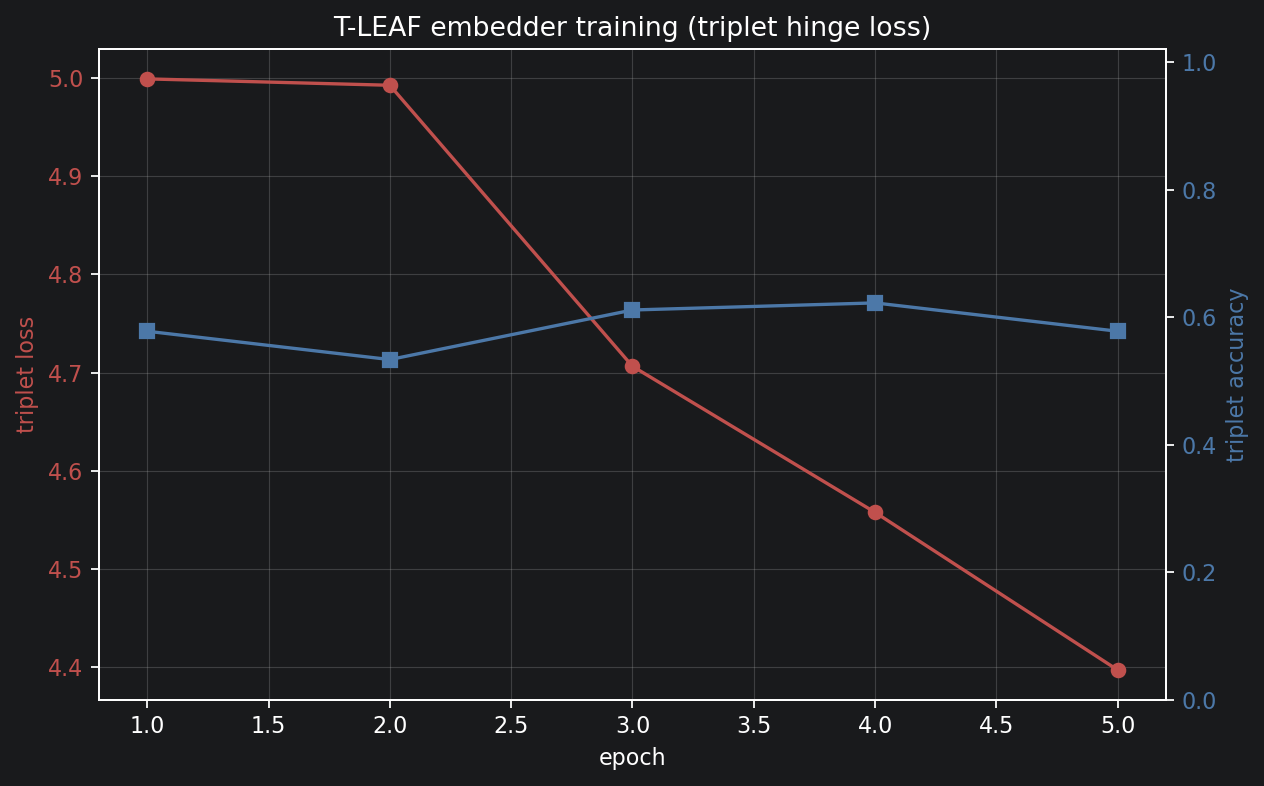

final triplet ranking accuracy: 0.578


In [9]:
if constraints:
    space = FeatureSpace.create(vocab.activities, prop_dim=50, node_dim=100,
                                seed=config.seed, device=device)
    embedder = HierarchicalEmbedder(aggregation="random_walk", normalize=False,
                                    meta_layers=2).to(device)
    emb_history = train_embedder(
        embedder, space, constraints, vocab.activities,
        EmbedderConfig(epochs=EMBEDDER_EPOCHS, triplets_per_constraint=12,
                       margin=5.0, learning_rate=2e-3, seed=config.seed),
        device=device, verbose=True,
    )
    plots.plot_embedder_training(emb_history, OUTPUT_DIR / "embedder_training.png")
    display(Image(filename=str(OUTPUT_DIR / "embedder_training.png")))
    print(f"final triplet ranking accuracy: {emb_history['triplet_accuracy'].iloc[-1]:.3f}")
else:
    print("no constraints mined -> embedder branch unavailable")

## 6. The grid: label noise × training-set size

`run_corruption_grid` does the heavy lifting. The symbolic layer above is rebuilt
once internally from the full clean training set, then for every
`(model, train_fraction, noise)` cell it subsamples the training cases, corrupts
that fraction of training targets, trains the variants and evaluates them on the
clean test set — one tidy row per evaluated model. Cached results are reused
unless `FORCE_RERUN=True`.

In [10]:
RESULTS_CSV.parent.mkdir(parents=True, exist_ok=True)
cached = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else None
compatible = cached is not None and "train_fraction" in cached.columns
have = compatible and (cached["dataset"] == DATASET_NAME).any()

if FORCE_RERUN or not have:
    grid = run_corruption_grid(
        DATA_PATH, dataset_name=DATASET_NAME,
        model_kinds=tuple(MODELS), noise_levels=tuple(NOISE_LEVELS),
        train_fractions=tuple(TRAIN_FRACTIONS), variants=tuple(VARIANTS),
        epochs=EPOCHS, embedder_epochs=EMBEDDER_EPOCHS, logic_weight=LOGIC_WEIGHT,
        seed=SEED, drop_unseen=DROP_UNSEEN, max_cases=MAX_CASES, verbose=True,
    )
    others = cached[cached["dataset"] != DATASET_NAME] if compatible else None
    combined = grid if others is None else pd.concat([others, grid], ignore_index=True)
    combined.to_csv(RESULTS_CSV, index=False)
else:
    grid = cached[cached["dataset"] == DATASET_NAME].reset_index(drop=True)
    print(f"loaded cached results for {DATASET_NAME}")

METRICS = ["accuracy", "macro_f1", "macro_precision", "macro_recall", "top_k_accuracy",
           "violation_rate", "forbidden_mass", "precedence_violation_rate"]
display(grid[["architecture", "variant", "train_fraction", "noise_level"] + METRICS]
        .sort_values(["architecture", "variant", "train_fraction", "noise_level"])
        .round(4).reset_index(drop=True))

embedder epoch 01 loss=4.9991 acc=0.561
embedder epoch 02 loss=4.9913 acc=0.539
embedder epoch 03 loss=4.6050 acc=0.594
embedder epoch 04 loss=4.6300 acc=0.589
embedder epoch 05 loss=4.5574 acc=0.589
[Sepsis_Case] gru frac=1 noise=0.00 (735 cases, 0/10740 corrupted)
[Sepsis_Case] gru frac=1 noise=0.10 (735 cases, 1074/10740 corrupted)
[Sepsis_Case] gru frac=1 noise=0.25 (735 cases, 2685/10740 corrupted)
[Sepsis_Case] gru frac=1 noise=0.40 (735 cases, 4296/10740 corrupted)
[Sepsis_Case] gru frac=0.5 noise=0.00 (368 cases, 0/5525 corrupted)
[Sepsis_Case] gru frac=0.5 noise=0.10 (368 cases, 552/5525 corrupted)
[Sepsis_Case] gru frac=0.5 noise=0.25 (368 cases, 1381/5525 corrupted)
[Sepsis_Case] gru frac=0.5 noise=0.40 (368 cases, 2210/5525 corrupted)
[Sepsis_Case] gru frac=0.25 noise=0.00 (184 cases, 0/2724 corrupted)
[Sepsis_Case] gru frac=0.25 noise=0.10 (184 cases, 272/2724 corrupted)
[Sepsis_Case] gru frac=0.25 noise=0.25 (184 cases, 681/2724 corrupted)
[Sepsis_Case] gru frac=0.25 nois

,architecture,variant,train_fraction,noise_level,accuracy,macro_f1,macro_precision,macro_recall,top_k_accuracy,violation_rate,forbidden_mass,precedence_violation_rate
0,gru,baseline,0.125,0.00,0.6586,0.4660,0.4914,0.4602,0.9185,0.0005,0.0088,0.0019
1,gru,baseline,0.125,0.10,0.6475,0.4525,0.4734,0.4517,0.9013,0.0042,0.0365,0.0042
2,gru,baseline,0.125,0.25,0.6392,0.4519,0.4855,0.4465,0.8861,0.0005,0.0619,0.0065
3,gru,baseline,0.125,0.40,0.6170,0.4530,0.4590,0.4513,0.8462,0.0111,0.1354,0.0088
4,gru,baseline,0.250,0.00,0.6670,0.4702,0.4978,0.4680,0.9236,0.0000,0.0055,0.0019
...,...,...,...,...,...,...,...,...,...,...,...,...
123,lstm,embedder,0.500,0.40,0.6378,0.4568,0.4777,0.4543,0.8898,0.0005,0.1205,0.0009
124,lstm,embedder,1.000,0.00,0.6748,0.4858,0.5060,0.4801,0.9236,0.0000,0.0034,0.0005
125,lstm,embedder,1.000,0.10,0.6517,0.4666,0.4797,0.4699,0.9250,0.0000,0.0305,0.0005
126,lstm,embedder,1.000,0.25,0.6637,0.4713,0.4806,0.4701,0.9199,0.0000,0.0729,0.0005


## 7. Experiment A: the clean corner

The classic next-activity comparison is the clean, full-data corner of the grid
(`train_fraction = 1.0`, `noise = 0.0`). On a log whose directly-follows
structure the baseline already absorbs, logic typically barely moves single-step
accuracy — the value of the symbolic prior shows up as the data gets dirtier and
scarcer (§8).

In [11]:
clean = grid[(grid.train_fraction == 1.0) & (grid.noise_level == 0.0)]
display(clean.set_index(["architecture", "variant"])[
    ["accuracy", "macro_f1", "top_k_accuracy", "forbidden_mass", "precedence_violation_rate"]
].round(4))

accuracy  macro_f1  top_k_accuracy  forbidden_mass  precedence_violation_rate
architecture variant                                                                                     
gru          baseline         0.6688    0.4893          0.9333          0.0028                     0.0005
             baseline_mask    0.6688    0.4893          0.9333          0.0000                     0.0005
             checker          0.6651    0.4878          0.9338          0.0021                     0.0005
             embedder         0.6660    0.4893          0.9213          0.0030                     0.0005
lstm         baseline         0.6707    0.4862          0.9333          0.0031                     0.0005
             baseline_mask    0.6707    0.4862          0.9333          0.0000                     0.0005
             checker          0.6716    0.4764          0.9342          0.0015                     0.0005
             embedder         0.6748    0.4858          0.9236          0.0034                     0.0005

## 8. Results across regimes

Pivot tables (rows = architecture × variant) at full data, plus learning curves
for the first architecture. Read **accuracy** (does it survive?) against
**forbidden_mass** / **precedence_violation_rate** (does the clean symbolic prior
keep the model conformant?). `baseline+mask` is conformant by construction.

In [12]:
for metric in ["accuracy", "forbidden_mass", "precedence_violation_rate"]:
    print(f"\n### {metric}  (rows: architecture x variant | cols: noise) @ train_fraction=1.0")
    sub = grid[grid.train_fraction == 1.0]
    display(sub.pivot_table(index=["architecture", "variant"],
                            columns="noise_level", values=metric).round(4))


### accuracy  (rows: architecture x variant | cols: noise) @ train_fraction=1.0


noise_level                   0.00    0.10    0.25    0.40
architecture variant                                      
gru          baseline       0.6688  0.6818  0.6637  0.6647
             baseline_mask  0.6688  0.6818  0.6637  0.6651
             checker        0.6651  0.6739  0.6674  0.6633
             embedder       0.6660  0.6531  0.6526  0.6258
lstm         baseline       0.6707  0.6753  0.6730  0.6693
             baseline_mask  0.6707  0.6753  0.6730  0.6693
             checker        0.6716  0.6744  0.6702  0.6670
             embedder       0.6748  0.6517  0.6637  0.6387


### forbidden_mass  (rows: architecture x variant | cols: noise) @ train_fraction=1.0


noise_level                   0.00    0.10    0.25    0.40
architecture variant                                      
gru          baseline       0.0028  0.0283  0.0714  0.1160
             baseline_mask  0.0000  0.0000  0.0000  0.0000
             checker        0.0021  0.0190  0.0502  0.0832
             embedder       0.0030  0.0302  0.0726  0.1090
lstm         baseline       0.0031  0.0301  0.0725  0.1161
             baseline_mask  0.0000  0.0000  0.0000  0.0000
             checker        0.0015  0.0203  0.0507  0.0832
             embedder       0.0034  0.0305  0.0729  0.1126


### precedence_violation_rate  (rows: architecture x variant | cols: noise) @ train_fraction=1.0


noise_level                   0.00    0.10    0.25    0.40
architecture variant                                      
gru          baseline       0.0005  0.0005  0.0005  0.0019
             baseline_mask  0.0005  0.0005  0.0005  0.0019
             checker        0.0005  0.0005  0.0005  0.0019
             embedder       0.0005  0.0005  0.0005  0.0009
lstm         baseline       0.0005  0.0005  0.0009  0.0009
             baseline_mask  0.0005  0.0005  0.0009  0.0009
             checker        0.0005  0.0005  0.0005  0.0009
             embedder       0.0005  0.0005  0.0005  0.0009

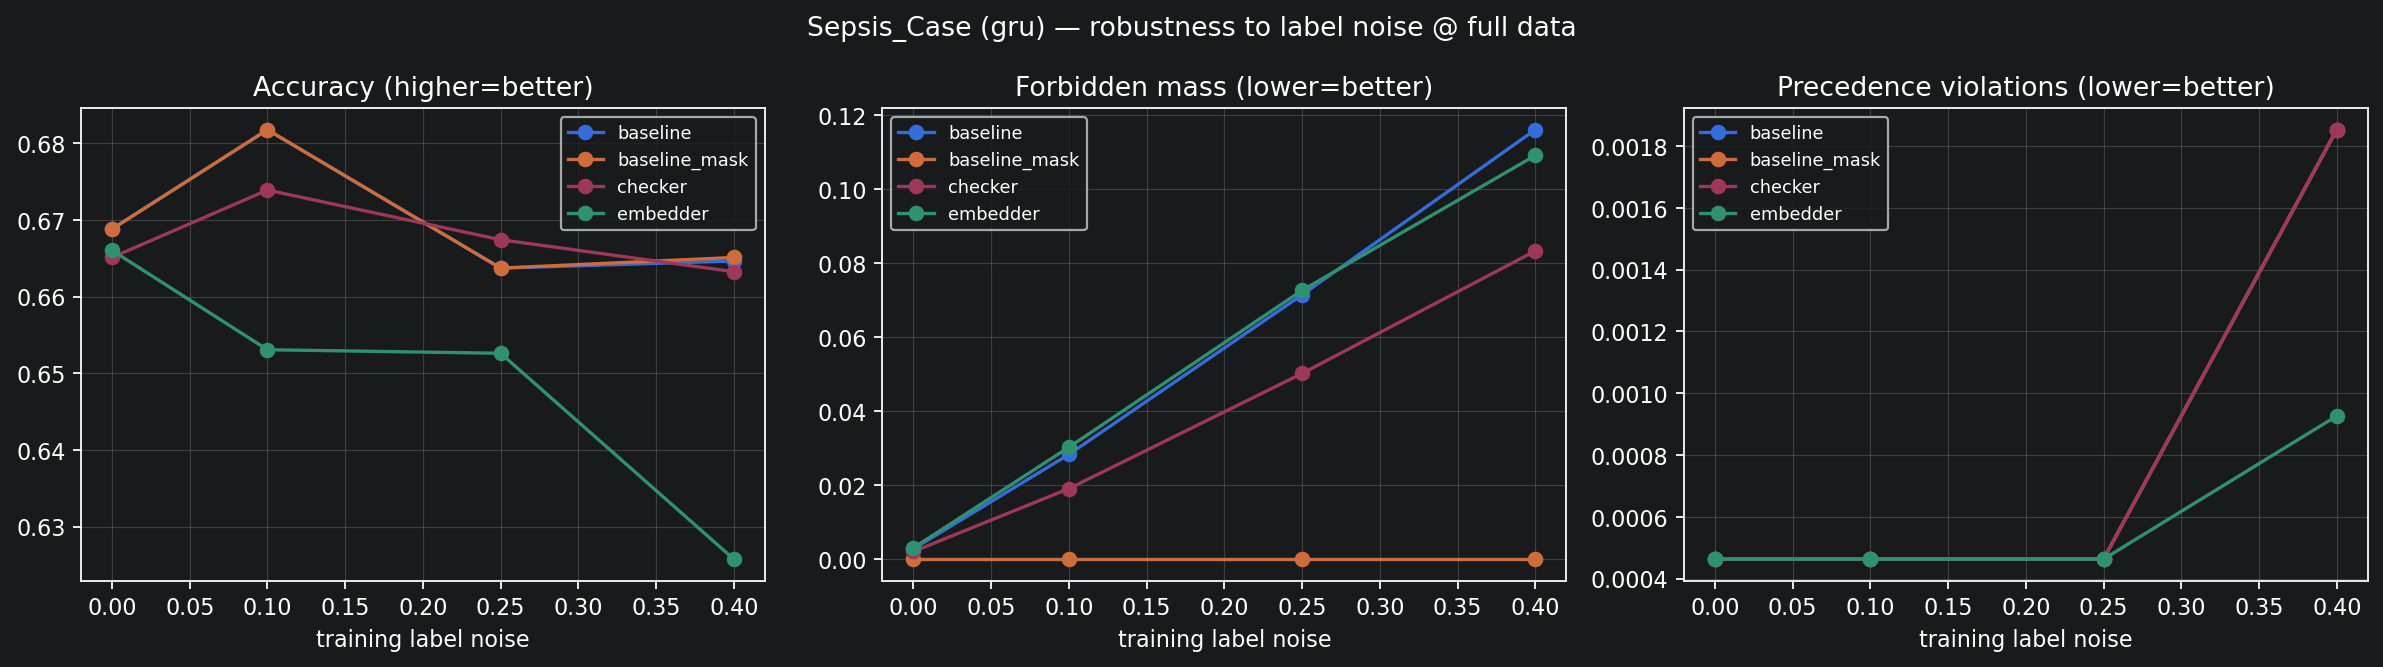

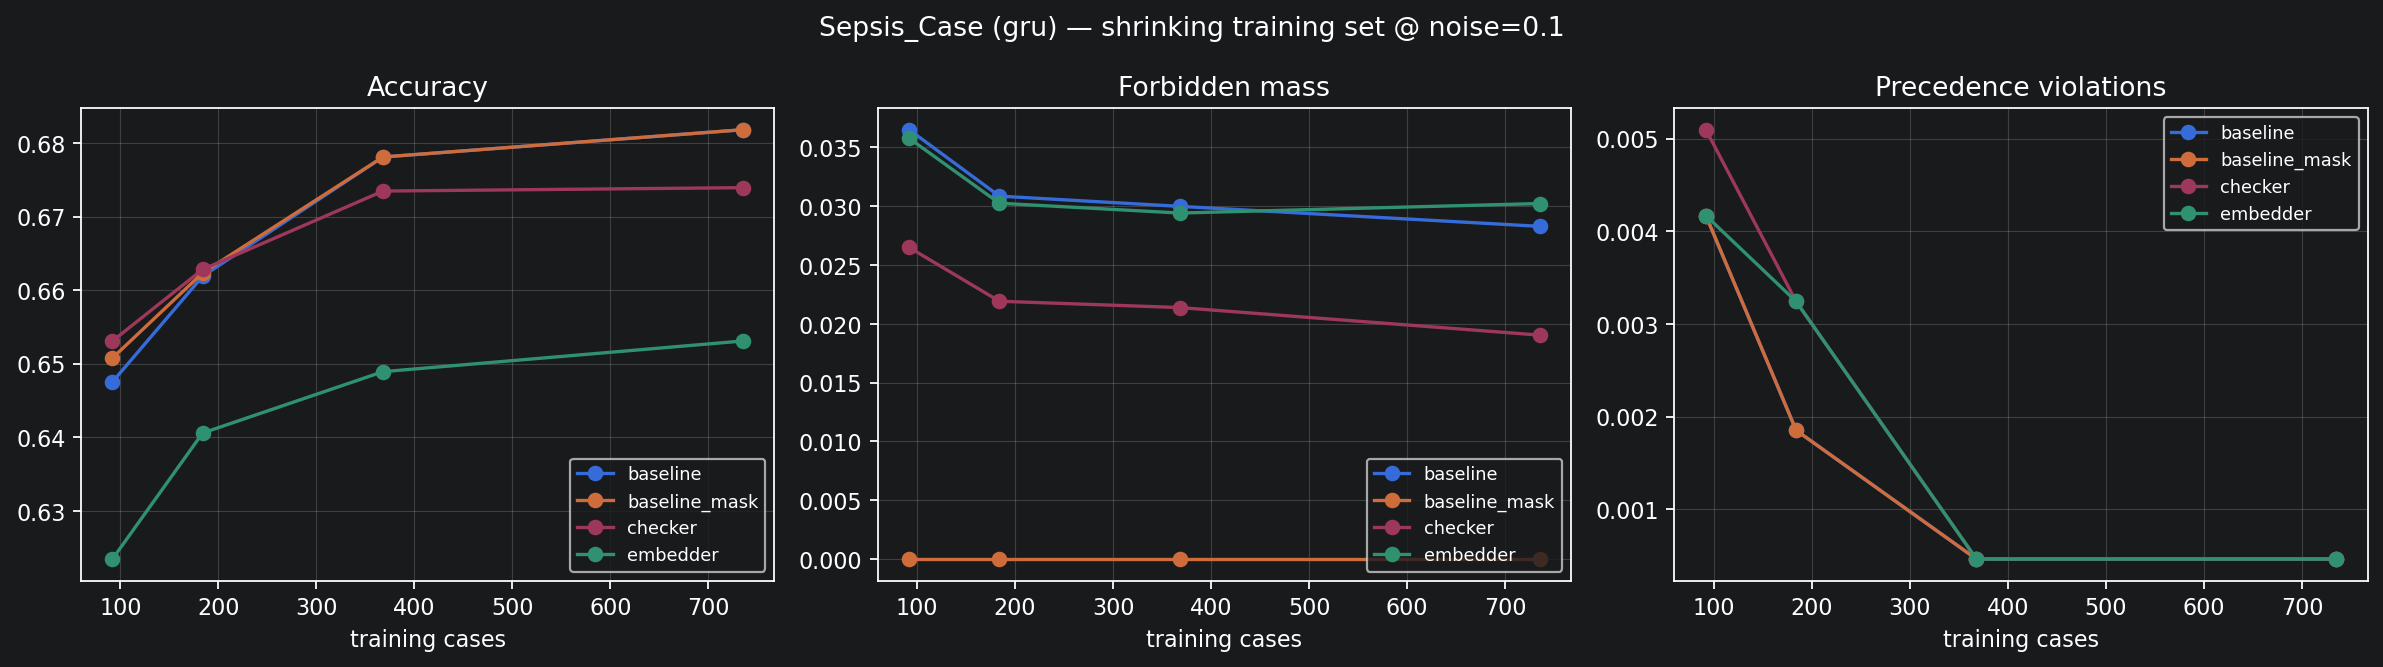

In [13]:
arch = MODELS[0]

full = grid[(grid.train_fraction == 1.0) & (grid.architecture == arch)]
plots.plot_fraction_curves(
    full, ["accuracy", "forbidden_mass", "precedence_violation_rate"],
    OUTPUT_DIR / "noise_curves.png", mode_col="variant",
    x_col="noise_level", x_label="training label noise",
    titles={"accuracy": "Accuracy (higher=better)",
            "forbidden_mass": "Forbidden mass (lower=better)",
            "precedence_violation_rate": "Precedence violations (lower=better)"},
    suptitle=f"{DATASET_NAME} ({arch}) — robustness to label noise @ full data")
display(Image(filename=str(OUTPUT_DIR / "noise_curves.png")))

scarce = grid[(grid.noise_level == 0.1) & (grid.architecture == arch)]
plots.plot_fraction_curves(
    scarce, ["accuracy", "forbidden_mass", "precedence_violation_rate"],
    OUTPUT_DIR / "scarcity_curves.png", mode_col="variant",
    x_col="n_train_cases", x_label="training cases",
    titles={"accuracy": "Accuracy", "forbidden_mass": "Forbidden mass",
            "precedence_violation_rate": "Precedence violations"},
    suptitle=f"{DATASET_NAME} ({arch}) — shrinking training set @ noise=0.1")
display(Image(filename=str(OUTPUT_DIR / "scarcity_curves.png")))

## 9. Conclusions

Read the numbers and curves above for this dataset:

- **Robustness to noise** — how each variant's accuracy degrades as more training
  labels are corrupted, and whether `checker`/`embedder` degrade more gently than
  `baseline` by leaning on the clean symbolic prior.
- **Scarcity** — whether the symbolic prior helps more when training cases are few
  (`1/4`, `1/8`), the regime where a data-only model has least to learn from.
- **Conformance** — `forbidden_mass` / `precedence_violation_rate` show whether
  predictions stay on legal transitions; `baseline+mask` enforces this at
  inference, `checker`/`embedder` push it into the weights during training.

The side-by-side comparison **across the three datasets** (and combined figures)
lives in the dedicated analysis notebook, which loads
`runs/benchmark_corruption.csv`.